# Capacité numérique – diffusion thermique
On cherche à résoudre numériquement l’équation
$$
\frac{\partial T}{\partial t} = K\frac{\partial^2T}{\partial x^2}\tag{1}
$$
à l’intérieur d’une paroi localisée entre les abscisses $x=0$ et $x=e$. On divise cette étendue spatiale en $Nx$ intervalles, chacun de largeur $\Delta x = \frac{e}{Nx}$. Le $x$-ième point de cette décomposition a pour abscisse $x_i = i\Delta x = i\frac e{Nx}$. On a à l’ordre 2 :
$$
T(x+\Delta x) \simeq T(x,t) + \Delta x\frac{\partial T}{\partial x}(x,t) + \frac{(\Delta x)^2}{2}\frac{\partial^2 T}{\partial x^2}(x,t)
$$
et
$$
T(x-\Delta x) \simeq T(x,t) - \Delta x\frac{\partial T}{\partial x}(x,t) + \frac{(\Delta x)^2}{2}\frac{\partial^2 T}{\partial x^2}(x,t)
$$
d’où, en sommant ces deux relations :
$$
T(x+\Delta x,t) + T(x-\Delta x,t) \simeq 2T(x,t) + (\Delta x)^2\frac{\partial^2 T}{\partial x^2}(x,t)
$$
soit
$$
\frac{\partial^2 T}{\partial x^2}(x,t) \simeq \frac{1}{(\Delta x)^2}\Big(T(x+\Delta x,t) + T(x-\Delta x,t) - 2T(x,t)\Big)
$$
On note $T_i^k$ la température $T(x_i,t_k)$ évaluée au point d’abscisse $x_i$ à l’instant $t_k = k\Delta t$ avec $\Delta t$ le pas de temps. On a alors
$$
\frac{\partial^2 T}{\partial x^2}(x_i,t_k) \simeq \frac{1}{(\Delta x)^2}\Big(T_{i+1}^k + T_{i-1}^k - 2T_i^k\Big)
$$
Par ailleurs, on a à l’ordre 1 la relation
$$
T_i^{k+1} = T(x_i,t_k+\Delta t) \simeq T(x_i,t_k) + \Delta t\frac{\partial T}{\partial t}(x_i,t_k) = T_i^k + \Delta t\frac{\partial T}{\partial t}(x_i,t_k)
$$
de laquelle on tire
$$
\frac{\partial T}{\partial t}(x_i,t_k) \simeq \frac{1}{\Delta t}\Big(T_i^{k+1} - T_i^k\Big)
$$
L’équation $(1)$ s’écrit alors
$$
\frac{1}{\Delta t}\Big(T_i^{k+1} - T_i^k\Big) = K\frac{1}{(\Delta x)^2}\Big(T_{i+1}^k + T_{i-1}^k - 2T_i^k\Big)
$$
soit en posant $r=K\frac{\Delta t}{(\Delta x)^2}$ :
$$
T_i^{k+1} = T_i^k(1-2r) + rT_{i+1}^k + rT_{i-1}^k
$$
Cette équation est valable pour $i$ tel que $1 \leqslant i \leqslant Nx-1$, les conditions aux limites s’écrivent, pour tout $k \geqslant 0$
$$
T_0^k = T_{\text{int}} \qquad \text{et}\qquad T_{Nx}^k = T_\text{ext2}
$$
et la condition initiale s’écrit, pour $i$ tel que $0 \leq i \leq Nx$ :
$$
T_i^0 = \frac{T_\text{ext1}-T_\text{int}}{e}\cdot i\Delta x + T_\text{int} = i\cdot\frac{T_\text{ext1}-T_\text{int}}{Nx} + T_\text{int}
$$
On donc besoin, pour calculer la valeur de la température à un temps donné pour une valeur de $x$ donnée de la valeur de la température à l’instant précédent pour ce point et les deux deux points adjacents. Je vais implémenter le programme en utilisant une matrice dont **chaque ligne représente le profil de température à l’intérieur de la paroi à un instant donné**. 

In [7]:
# Paramètres de la simulation
Tint = 20
Text1 = 10
Text2 = -10
e = 0.4 # Épaisseur de la paroi
Nx = 100 # Nombre de subdivisions de l’étendue spatiale de la paroi
Delta_t = 1 # Résolution temporelle de la simulation en secondes

conductivité_thermique = 1.65 # W/(m.K)
masse_volumique = 2150 # kg/m3
capacité_thermique = 1000 # J/(kg.K)
# Fin des paramètres de la simulation

K = (conductivité_thermique)/(masse_volumique * capacité_thermique)
Delta_x = e / Nx
r = K * Delta_t / ((Delta_x)**2)
assert r < 1/2

def Ti_suivant(temp_k,i):
    assert i >= 1 and i <= Nx-1
    return temp_k[i]*(1-2*r) + r*temp_k[i+1] + r*temp_k[i-1]

def schema_explicite(durées):
    """
    schema_explicite(durées) est une liste de profils de températures aux instants durées[0], …, durées[-1].
    """
    temperatures = [[i * ((Text1 - Tint)/Nx) + Tint for i in range(Nx+1)]]

    k_intermédiaires = [int(d / Delta_t) for d in durées]
    max_k = max(k_intermédiaires) / Delta_t
    
    for k in range(1,max(k_intermédiaires)+1):
      temperatures.append([Tint] + [Ti_suivant(temperatures[-1], i) for i in range(1,Nx)] + [Text2])

    return [temperatures[k] for k in k_intermédiaires]

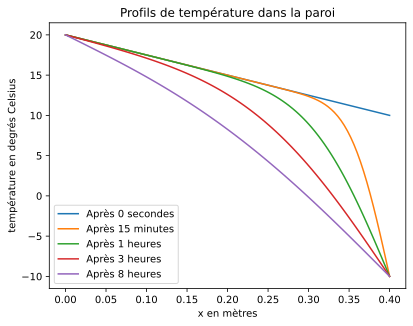

In [11]:
import matplotlib.pyplot as plt

durées = [0, 60*15, 60*60, 60*60*3, 60*60*8] # en secondes
températures = schema_explicite(durées)
x = [Delta_x*i for i in range(len(températures[0]))]

def format_temps(secondes):
    if secondes < 60:
        return f"{secondes} secondes"
    if secondes < 3600:
        return f"{secondes//60} minutes"
    if secondes < 3600*24:
        return f"{secondes//3600} heures"
    return f"{secondes//(3600*24)} jours"

for durée,temp in zip(durées,températures):
    plt.plot(x,temp, label=f"Après {format_temps(durée)}")

%config InlineBackend.figure_format = 'svg'
plt.title("Profils de température dans la paroi")
plt.xlabel("x en mètres")
plt.ylabel("température en degrés Celsius")
plt.legend()